In [1]:
import  pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
features = pd.read_csv("data/features_with_defenders.csv")
shots = pd.read_csv("data/shots.csv")

In [26]:
features.head()

,distance,angle,x,y_centered,is_header,is_right_foot,is_left_foot,is_open_play,is_corner,is_free_kick,is_counter,is_volley,is_one_on_one,is_open_goal,under_pressure,is_first_time,defenders_in_cone,is_goal
0,23.510423,19.303454,96.5,0.7,0,0,1,1,0,0,0,0,0,0,1,1,3.0,0
1,36.444616,12.412158,83.9,5.0,0,0,1,0,0,0,0,0,0,0,0,1,1.0,1
2,33.238532,13.708899,86.8,1.6,0,1,0,0,0,1,0,0,0,0,0,0,4.0,0
3,15.423683,25.112519,107.0,8.3,0,0,1,0,1,0,0,0,0,0,0,0,4.0,0
4,8.420214,44.313540,113.3,5.1,0,1,0,0,0,0,1,0,0,0,0,1,1.0,0


In [4]:
shots.head()    

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_other,...,bad_behaviour_card,block_save_block,goalkeeper_shot_saved_off_target,shot_saved_off_target,goalkeeper_success_in_play,shot_follows_dribble,half_start_late_video_start,goalkeeper_lost_in_play,pass_backheel,goalkeeper_penalty_saved_to_post
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print(f"Number of shots token: {len(features):,}")
print(f"Number of Goals: {features['is_goal'].sum()}")
print(f"Conversion Rate: {features['is_goal'].mean():.2%}")

Number of shots token: 4,540
Number of Goals: 504
Conversion Rate: 11.10%


In [6]:
final_match_id = shots[
    (shots['match_id'].isin([3869685]))
]['match_id'].unique()

shots_with_features = shots.reset_index(drop=True)
final_mask = shots_with_features['match_id'] == 3869685
final_features = features[final_mask].copy()
remaining_features = features[~final_mask].copy()

print(f"finally match id: {final_match_id}")
print(f"Final shots (held out): {len(final_features)}")
print(f"Remaining shots: {len(remaining_features)}")

finally match id: [3869685]
Final shots (held out): 38
Remaining shots: 4502


In [7]:
# Match the features to the shots by index to get match_ids
shots_aligned = shots.reset_index(drop=True)
features_aligned = features.reset_index(drop=True)

# How many unique matches?
print(f"Total shots in features file: {len(features)}")
print(f"Unique matches in shots: {shots['match_id'].nunique()}")

# Roughly what date range?
if 'kick_off' in shots.columns or 'match_date' in shots.columns:
    date_col = 'match_date' if 'match_date' in shots.columns else 'kick_off'
    print(f"Date range: {shots[date_col].min()} to {shots[date_col].max()}")

Total shots in features file: 4540
Unique matches in shots: 179


In [8]:
x = remaining_features.drop(columns=['is_goal'])
y = remaining_features['is_goal']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42, stratify = y)

print(f"Train: {len(X_train):,} shots, {y_train.sum()} goals ({y_train.mean():.1%})")
print(f"Test:  {len(X_test):,} shots, {y_test.sum()} goals ({y_test.mean():.1%})")

Train: 3,601 shots, 394 goals (10.9%)
Test:  901 shots, 98 goals (10.9%)


## Logistic Regression 

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(max_iter=1000, random_state=42))
])

log_reg_pipeline.fit(X_train, y_train)
print("logistic Regression trained")


logistic Regression trained


In [10]:
y_pred_proba_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]
y_pred_lr = log_reg_pipeline.predict(X_test)

print(f"Sample predicted probabilities: {y_pred_proba_lr[:5]}")
print(f"Sample binary predictions: {y_pred_lr[:5]}")

Sample predicted probabilities: [0.01750926 0.10624173 0.4175637  0.02641876 0.02397395]
Sample binary predictions: [0 0 0 0 0]


In [11]:
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score

def evalute_model(y_true, y_pred_proba, model_name):
    ll = log_loss(y_true, y_pred_proba)
    brier = brier_score_loss(y_true, y_pred_proba)
    auc = roc_auc_score(y_true, y_pred_proba)


    print(f"\n--- {model_name } ------")
    print(f"Log Loss: {ll:.4f}")
    print(f"Brier Score: {brier:.4f}")
    print(f"AUC: {auc:.4f}")

    return {"log_loss": ll, "brier_score": brier, "auc": auc}

log_reg_metrics = evalute_model(y_test, y_pred_proba_lr, "Logistic Regression")



--- Logistic Regression ------
Log Loss: 0.2735
Brier Score: 0.0780
AUC: 0.8077


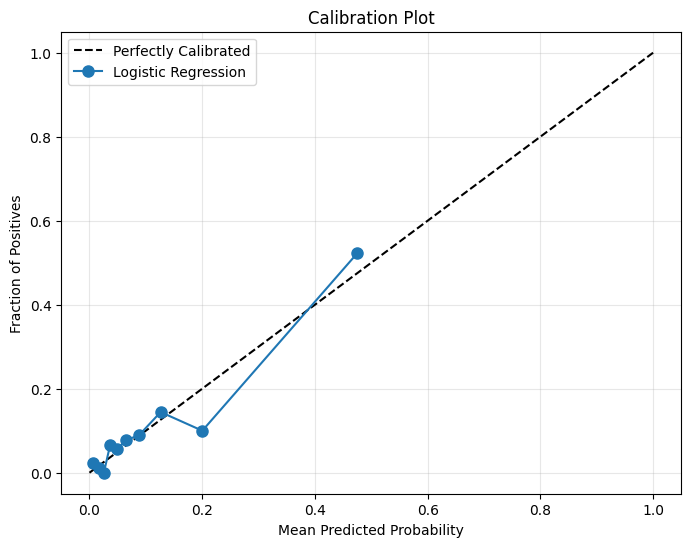

In [12]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

def plot_calibration_curve(y_true, y_pred_proba, model_name, ax=None):
    prob_true, prob_pred = calibration_curve(y_true, y_pred_proba, n_bins=10, strategy='quantile')

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot([0,1],[0,1], 'k--', label='Perfectly Calibrated')
    ax.plot(prob_pred, prob_true, 'o-', label=model_name, markersize=8)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title('Calibration Plot')
    ax.legend()
    ax.grid(alpha=0.3)
    return ax

plot_calibration_curve(y_test, y_pred_proba_lr, "Logistic Regression")
plt.savefig('outputs/02_calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()
    

In [13]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators = 300,
    max_depth= 4,
    learning_rate = 0.05,
    min_child_weight = 10,
    subsample= 0.8,
    colsample_bytree = 0.8,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=30
)

xgb_model.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose = False
)

print(f'Best Iteration: {xgb_model.best_iteration}')

Best Iteration: 56



--- XGBoost ------
Log Loss: 0.2783
Brier Score: 0.0788
AUC: 0.7840


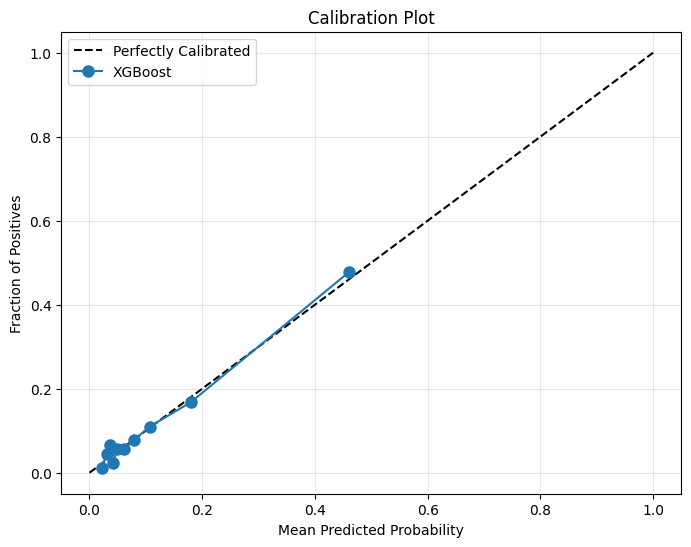

In [14]:
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
xgb_metrics = evalute_model(y_test, y_pred_proba_xgb, "XGBoost")
plot_calibration_curve(y_test, y_pred_proba_xgb, "XGBoost") 
plt.savefig('outputs/02_calibration_curve_xgb.png', dpi=150, bbox_inches='tight')
plt.show()




--- Calibrated XGBoost ------
Log Loss: 0.2842
Brier Score: 0.0802
AUC: 0.7809


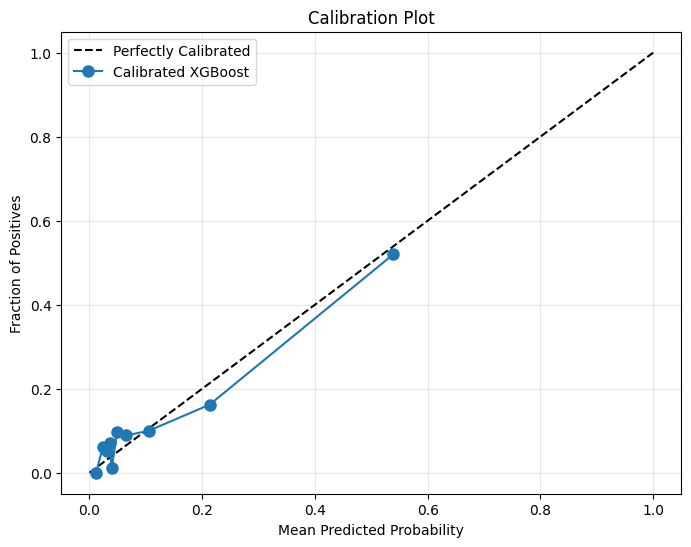

In [15]:
from sklearn.calibration import CalibratedClassifierCV

xgb_for_cal = XGBClassifier(
    n_estimators = xgb_model.best_iteration,
    max_depth= 4,
    learning_rate = 0.05,
    min_child_weight = 10,
    subsample= 0.8,
    colsample_bytree = 0.8,
    random_state=42,
)

calibtated_xgb = CalibratedClassifierCV(xgb_for_cal, method='isotonic', cv=5)
calibtated_xgb.fit(X_train, y_train)

y_pred_proba_calibrated_xgb = calibtated_xgb.predict_proba(X_test)[:, 1]
cal_metrics = evalute_model(y_test, y_pred_proba_calibrated_xgb, "Calibrated XGBoost")
plot_calibration_curve(y_test, y_pred_proba_calibrated_xgb, "Calibrated XGBoost")
plt.savefig('outputs/02_calibration_curve_calibrated_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Test set shape: {X_test.shape}")

SHAP values shape: (901, 17)
Test set shape: (901, 17)


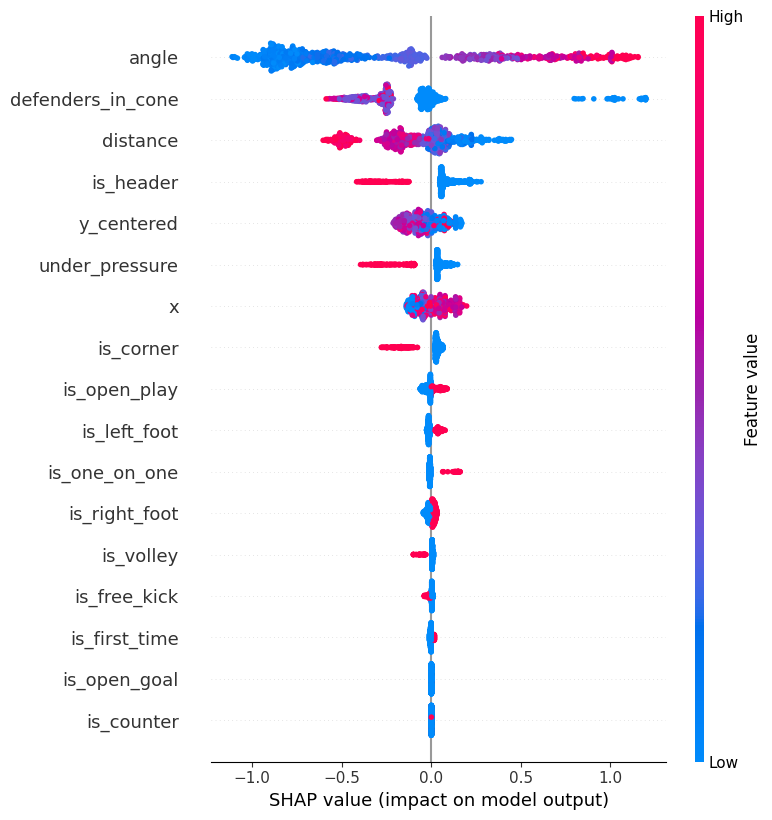

In [17]:
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig('outputs/02_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

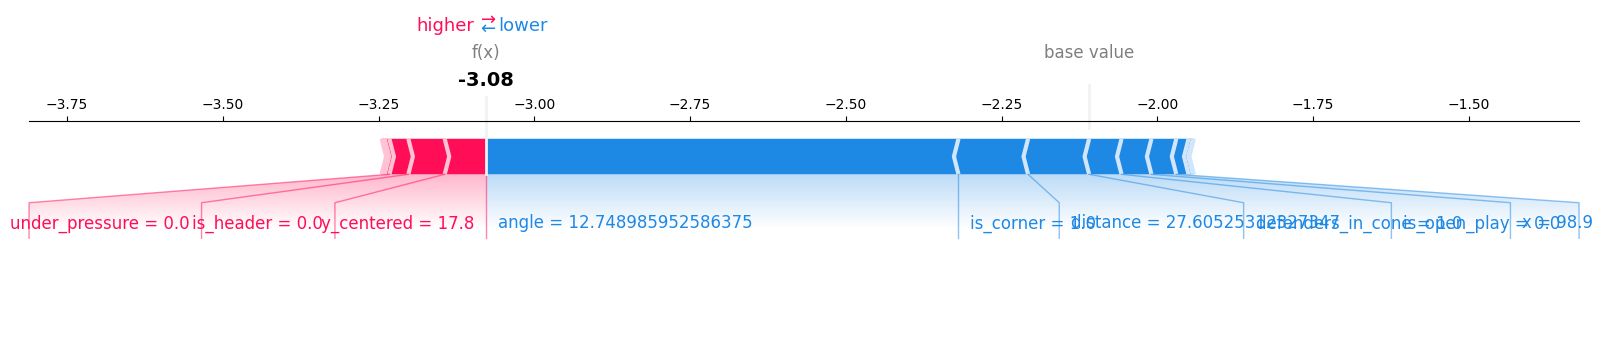

In [18]:
final_shot_index = X_test.index[0]
shap.initjs()

force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0],
    matplotlib=True,
    show=False,
    figsize=(20, 3)
)


plt.savefig('outputs/02_shap_force_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(log_reg_pipeline, 'models/logistic_regression_pipeline.pkl')
joblib.dump(xgb_model, 'models/xgb_model.pkl')
joblib.dump(calibtated_xgb, 'models/calibrated_xgb_model.pkl')


metrics_df = pd.DataFrame([
    {'model':'Logistic Regression', **log_reg_metrics},
    {'model':'XGBoost', **xgb_metrics},
    {'model':'Calibrated XGBoost', **cal_metrics}
])

metrics_df.to_csv('outputs/model_metrics.csv', index=False)
metrics_df

,model,log_loss,brier_score,auc
0,Logistic Regression,0.273490,0.078048,0.807717
1,XGBoost,0.278344,0.078801,0.783980
2,Calibrated XGBoost,0.284241,0.080232,0.780924


In [20]:
final_X_logistic = final_features.drop(columns=['is_goal'])
final_features['xg'] = log_reg_pipeline.predict_proba(final_X_logistic)[:, 1]

final_features.sort_values('xg', ascending=False).head(10)

,distance,angle,x,y_centered,is_header,is_right_foot,is_left_foot,is_open_play,is_corner,is_free_kick,is_counter,is_volley,is_one_on_one,is_open_goal,under_pressure,is_first_time,defenders_in_cone,is_goal,xg
623,4.534314,80.483032,116.6,3.0,0,1,0,1,0,0,0,0,0,0,0,1,1.0,1,0.575962
635,11.900420,37.156345,108.1,0.1,0,1,0,0,0,0,0,0,0,0,0,0,0.0,1,0.562455
628,11.900420,37.156345,108.1,0.1,0,1,0,0,0,0,0,0,0,0,0,0,0.0,1,0.562455
630,11.900420,37.156345,108.1,0.1,0,1,0,0,0,0,0,0,0,0,0,0,0.0,0,0.562455
634,11.900420,37.156345,108.1,0.1,0,1,0,0,0,0,0,0,0,0,0,0,0.0,1,0.562455
633,11.900420,37.156345,108.1,0.1,0,1,0,0,0,0,0,0,0,0,0,0,0.0,1,0.562455
610,12.000000,36.869898,108.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0.0,1,0.560342
625,12.000000,36.869898,108.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0.0,1,0.560342
631,11.900420,37.156345,108.1,0.1,0,0,1,0,0,0,0,0,0,0,0,0,0.0,1,0.559771
629,11.900420,37.156345,108.1,0.1,0,0,1,0,0,0,0,0,0,0,0,0,0.0,1,0.559771


In [21]:
final_X_xgb = final_features.drop(columns=['is_goal', 'xg'])
final_features['xg'] = xgb_model.predict_proba(final_X_xgb)[:, 1]

final_features.sort_values('xg', ascending=False).head(10)

,distance,angle,x,y_centered,is_header,is_right_foot,is_left_foot,is_open_play,is_corner,is_free_kick,is_counter,is_volley,is_one_on_one,is_open_goal,under_pressure,is_first_time,defenders_in_cone,is_goal,xg
631,11.90042,37.156345,108.1,0.1,0,0,1,0,0,0,0,0,0,0,0,0,0.0,1,0.724880
629,11.90042,37.156345,108.1,0.1,0,0,1,0,0,0,0,0,0,0,0,0,0.0,1,0.724880
635,11.90042,37.156345,108.1,0.1,0,1,0,0,0,0,0,0,0,0,0,0,0.0,1,0.722496
634,11.90042,37.156345,108.1,0.1,0,1,0,0,0,0,0,0,0,0,0,0,0.0,1,0.722496
630,11.90042,37.156345,108.1,0.1,0,1,0,0,0,0,0,0,0,0,0,0,0.0,0,0.722496
628,11.90042,37.156345,108.1,0.1,0,1,0,0,0,0,0,0,0,0,0,0,0.0,1,0.722496
633,11.90042,37.156345,108.1,0.1,0,1,0,0,0,0,0,0,0,0,0,0,0.0,1,0.722496
601,12.00000,36.869898,108.0,0.0,0,0,1,0,0,0,0,0,0,0,0,0,0.0,1,0.645374
625,12.00000,36.869898,108.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0.0,1,0.642642
610,12.00000,36.869898,108.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0.0,1,0.642642


In [22]:
final_X_calibrated = final_features.drop(columns=['is_goal', 'xg'])
final_features['xg'] = calibtated_xgb.predict_proba(final_X_calibrated)[:, 1]

final_features.sort_values('xg', ascending=False)

,distance,angle,x,y_centered,is_header,is_right_foot,is_left_foot,is_open_play,is_corner,is_free_kick,is_counter,is_volley,is_one_on_one,is_open_goal,under_pressure,is_first_time,defenders_in_cone,is_goal,xg
635,11.900420,37.156345,108.1,0.1,0,1,0,0,0,0,0,0,0,0,0,0,0.0,1,0.791136
630,11.900420,37.156345,108.1,0.1,0,1,0,0,0,0,0,0,0,0,0,0,0.0,0,0.791136
628,11.900420,37.156345,108.1,0.1,0,1,0,0,0,0,0,0,0,0,0,0,0.0,1,0.791136
633,11.900420,37.156345,108.1,0.1,0,1,0,0,0,0,0,0,0,0,0,0,0.0,1,0.791136
634,11.900420,37.156345,108.1,0.1,0,1,0,0,0,0,0,0,0,0,0,0,0.0,1,0.791136
631,11.900420,37.156345,108.1,0.1,0,0,1,0,0,0,0,0,0,0,0,0,0.0,1,0.782364
629,11.900420,37.156345,108.1,0.1,0,0,1,0,0,0,0,0,0,0,0,0,0.0,1,0.782364
610,12.000000,36.869898,108.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0.0,1,0.719482
601,12.000000,36.869898,108.0,0.0,0,0,1,0,0,0,0,0,0,0,0,0,0.0,1,0.719482
625,12.000000,36.869898,108.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0.0,1,0.719482


In [23]:
final_features.to_csv('data/WC_final_with_xg.csv', index=False)